<a href="https://colab.research.google.com/github/data-geass/machine-learning-practice/blob/main/pd%26plt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Повторение Pandas, Matplotlib

Начнем с повторения библотек Pandas и Matplotlib. В ML Pandas нужен для работы с данными, а Matplotlib для быстрой визуализации и проверки результата.

In [1]:
# скачиваем пандас с флагом -q (тихо, без терминала)
!pip install -q pandas

In [2]:
import pandas as pd

In [3]:
# прочитаем файл comma-separated values
df = pd.read_csv('/content/sample_data/mnist_test.csv')

In [4]:
df.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(9999, 785)

In [6]:
df1 = df['0']
df1.head()

,0
0,0
1,0
2,0
3,0
4,0


In [7]:
df2 = df[['0', '0.1', '1.3']]
df2.head()

KeyError: "['1.3'] not in index"

Ошибка KeyError - значит, что таких значений нету в столбцах

In [8]:
df2 = df[['0', '0.1', '0.3']]
df2.head()

,0,0.1,0.3
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [9]:
# создание гугл таблицы (оффтоп)
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df2)

https://docs.google.com/spreadsheets/d/1ajqz1QLKOE9UoznItM4pc98n4tu0feIKZMXByJa9I8g/edit#gid=0


In [10]:
# & - это логический оператор "И"
# | - это "ИЛИ"
# ~ - это "НЕ"

df3 = df2[(df2['0.1'] == 0) & (df2['0.1'] == 0)]
df3

,0,0.1,0.3
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
9994,0,0,0
9995,0,0,0
9996,0,0,0
9997,0,0,0


In [11]:
# сколько none значений
df2.isna().sum()

,0
0,0
0.1,0
0.3,0


In [12]:
series1 = pd.Series(['None', '1', '2'])

In [13]:
series1

,0
0,None
1,1
2,2


In [14]:
series1.isna()

,0
0,False
1,False
2,False


О, тут я ошибся... Надо было None без кавычек

In [15]:
series1 = pd.Series([None, '1', '2'])

In [16]:
series1.isna()

,0
0,True
1,False
2,False


In [17]:
s2 = series1.dropna()
s2

,0
1,1
2,2


In [18]:
s3 = series1.fillna(0)
s3

,0
0,0
1,1
2,2


In [19]:
# и наоборот, посмотрим те что не None
s3 = series1.notna()
s3

,0
0,False
1,True
2,True


In [20]:
x = {
    'Name': ['Rinat', 'Nikita', 'Kiril'],
    'Age': ['21', '23', '24']
}
ex1 = pd.DataFrame(x)
ex1

,Name,Age
0,Rinat,21
1,Nikita,23
2,Kiril,24


In [21]:
y = {
    'Name': ['Rinat', 'Nikita', 'Kiril'],
    'Salary': ['200000', '100000', '300000']
}

ex2 = pd.DataFrame(y)
ex2

,Name,Salary
0,Rinat,200000
1,Nikita,100000
2,Kiril,300000


In [28]:
df_search = ex2['Name'].str.contains('Rinat')
df_search[df_search == True]

,Name
0,True


In [30]:
df_search = df_search.rename('test')
df_search

,test
0,True
1,False
2,False


In [31]:
# потренируем join-ы, для этого создадим df
users = pd.DataFrame({
    "user_id": [1, 2, 3],
    "name": ["Иван", "Олег", "Анна"]
})

orders = pd.DataFrame({
    "user_id": [1, 1, 2],
    "amount": [500, 700, 300]
})

In [33]:
users

,user_id,name
0,1,Иван
1,2,Олег
2,3,Анна


In [34]:
orders

,user_id,amount
0,1,500
1,1,700
2,2,300


In [32]:
# inner join
users_inner = users.merge(orders, on='user_id', how='inner')
users_inner

,user_id,name,amount
0,1,Иван,500
1,1,Иван,700
2,2,Олег,300


In [35]:
# full join
users_inner = users.merge(orders, on='user_id', how='outer')
users_inner

,user_id,name,amount
0,1,Иван,500.0
1,1,Иван,700.0
2,2,Олег,300.0
3,3,Анна,NaN


In [36]:
# склеивание двух df
full_df = pd.concat([users, orders], axis=0)
full_df

,user_id,name,amount
0,1,Иван,NaN
1,2,Олег,NaN
2,3,Анна,NaN
0,1,NaN,500.0
1,1,NaN,700.0
2,2,NaN,300.0


In [37]:
full_df = pd.concat([users, orders], axis=1)
full_df

,user_id,name,user_id,amount
0,1,Иван,1,500
1,2,Олег,1,700
2,3,Анна,2,300


# Теперь перейдем к Matplotlib

In [40]:
!pip install -q matplotlib

In [42]:
import matplotlib.pyplot as plt

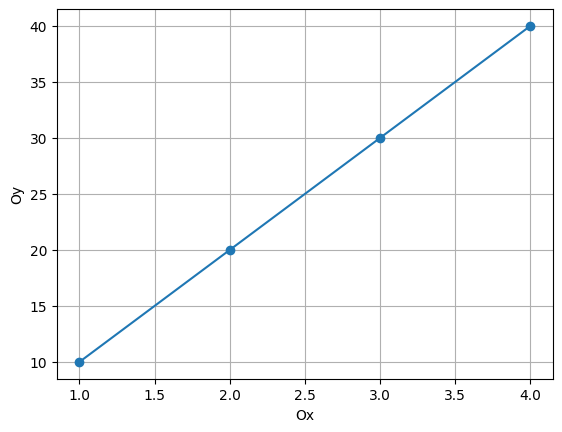

In [52]:
# построим линейный график
x1 = [1, 2, 3 , 4]
y1 = [10, 20, 30, 40]

plt.plot(x1, y1, marker = 'o')

plt.xlabel('Ox')
plt.ylabel('Oy')
plt.grid()

plt.show()

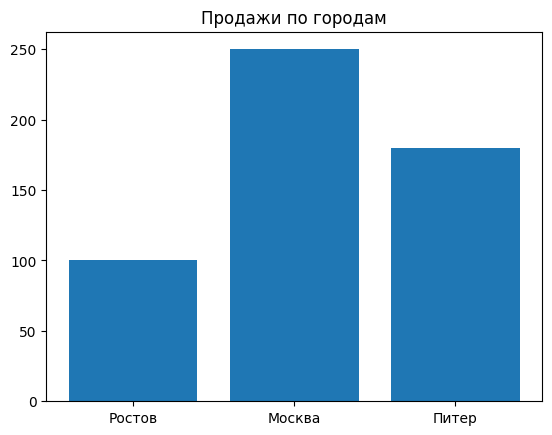

In [55]:
# построим столбчатую диаграмму
cities = ["Ростов", "Москва", "Питер"]
sales = [100, 250, 180]

plt.bar(cities, sales)

plt.title('Продажи по городам')

plt.show()

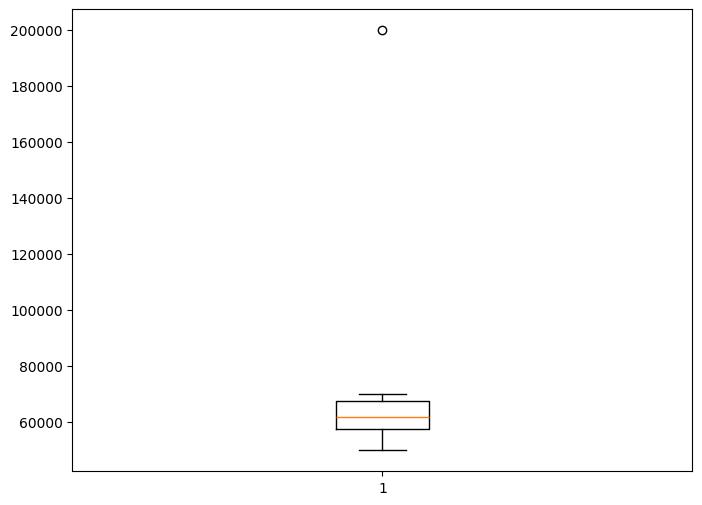

In [66]:
# ну, думаю, еще ящик с усами вспоним, чтобы выбросы видеть
# и этого вполне достаточно

x2 = ["Зарплата"]
y2 = [50000, 55000, 60000, 62000, 65000, 70000, 200000]

plt.figure(figsize=(8, 6))
plt.boxplot(y2)

plt.show()